In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/creditcard.csv")


In [3]:
df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21873,31906,1.285161,-0.701455,0.221870,-0.744753,-0.674967,0.034267,-0.631373,0.097860,-0.835749,...,0.083025,0.190059,-0.074942,-0.278466,0.463615,-0.223877,0.011735,0.000997,39.75,0.0
21874,31906,-0.345979,1.094568,1.282208,0.068241,-0.016965,-0.989567,0.693958,-0.050855,-0.333856,...,-0.266852,-0.723026,-0.003364,0.322646,-0.173496,0.073145,0.241997,0.097610,5.99,0.0
21875,31907,1.171852,0.718042,-0.227521,1.373722,0.152349,-0.949840,0.271427,-0.153000,-0.184297,...,-0.013584,0.088759,-0.059148,0.278992,0.589886,-0.319374,0.055064,0.058347,1.00,0.0
21876,31907,1.209330,-1.130242,1.614261,0.000265,-1.974416,0.262320,-1.369554,0.173769,0.639855,...,-0.520157,-0.573057,0.037646,0.488580,0.161446,1.067798,0.025745,0.028549,40.00,0.0


/tmp/ipykernel_2486/2681095916.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


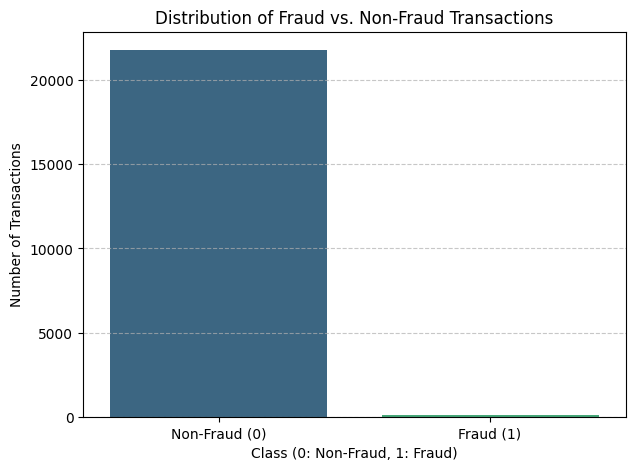


--- Chart Interpretation ---
The bar chart clearly illustrates a significant class imbalance in the dataset.
- Non-Fraudulent Transactions (Class 0): 21791 transactions
- Fraudulent Transactions (Class 1): 86 transactions
This severe imbalance (a vast majority of non-fraudulent versus a very small number of fraudulent transactions)
is a crucial factor to consider in fraud detection, as it can heavily influence model training and evaluation strategies.
--------------------------


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class (fraud vs non-fraud)
class_counts = df['Class'].value_counts()

# Create a bar chart
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribution of Fraud vs. Non-Fraud Transactions')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation of the chart (as comments):
# This bar chart visually represents the distribution of transaction classes.
# The x-axis shows the two classes: '0' for non-fraudulent transactions and '1' for fraudulent transactions.
# The y-axis displays the count of transactions for each class.
# The chart clearly illustrates the significant imbalance in the dataset, with a very large number of non-fraudulent transactions
# compared to a very small number of fraudulent transactions. This imbalance is a common characteristic of fraud detection datasets
# and is important to consider during model development (e.g., when choosing evaluation metrics or sampling techniques).

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The bar chart clearly illustrates a significant class imbalance in the dataset.")
print(f"- Non-Fraudulent Transactions (Class 0): {class_counts.get(0.0, 0)} transactions")
print(f"- Fraudulent Transactions (Class 1): {class_counts.get(1.0, 0)} transactions")
print(f"This severe imbalance (a vast majority of non-fraudulent versus a very small number of fraudulent transactions)")
print(f"is a crucial factor to consider in fraud detection, as it can heavily influence model training and evaluation strategies.")
print(f"--------------------------")

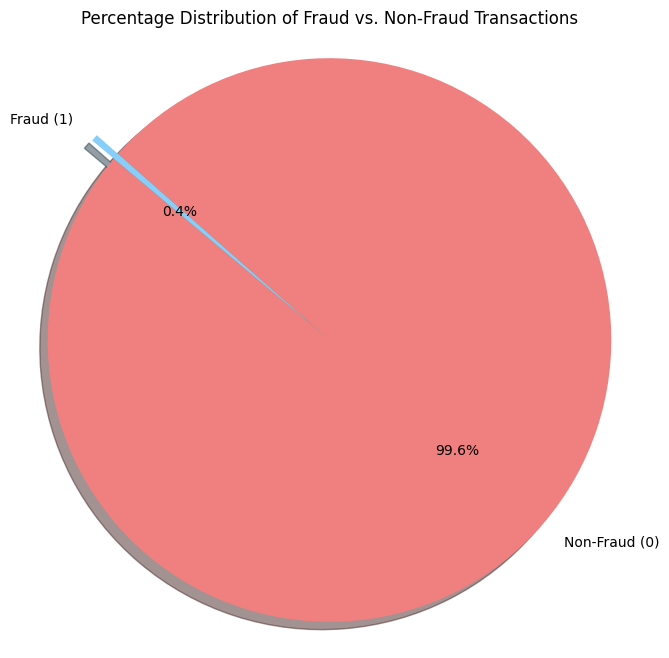


--- Chart Interpretation ---
The pie chart visually represents the proportion of fraud and non-fraud transactions in the dataset.
- Non-Fraudulent Transactions (Class 0): 21791 transactions, accounting for 99.6% of all valid transactions.
- Fraudulent Transactions (Class 1): 86 transactions, accounting for 0.4% of all valid transactions.
This chart clearly reinforces the severe class imbalance, showing that fraudulent transactions constitute a very small percentage of the total, which is a critical aspect for fraud detection model development.
--------------------------


In [6]:
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = df['Class'].value_counts(dropna=False)

# Handle potential NaN values by converting them to a string 'NaN' or dropping them
# For a pie chart, we usually want to visualize valid categories, so let's focus on 0.0 and 1.0
# If NaN exists and needs to be shown, we can include it, but typically we'd drop it or impute.
# For this purpose, let's assume we want to visualize only valid classes.
valid_class_counts = class_counts.loc[[0.0, 1.0]] if 0.0 in class_counts.index and 1.0 in class_counts.index else class_counts

# Define labels and sizes for the pie chart
labels = ['Non-Fraud (0)', 'Fraud (1)']
sizes = [valid_class_counts.get(0.0, 0), valid_class_counts.get(1.0, 0)]
colors = ['lightcoral', 'lightskyblue']
explode = (0, 0.1)  # only "explode" the 2nd slice (i.e. 'Fraud')

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage Distribution of Fraud vs. Non-Fraud Transactions')
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The pie chart visually represents the proportion of fraud and non-fraud transactions in the dataset.")
print(f"- Non-Fraudulent Transactions (Class 0): {valid_class_counts.get(0.0, 0)} transactions, accounting for {sizes[0]/(sum(sizes) if sum(sizes) > 0 else 1):.1%} of all valid transactions.")
print(f"- Fraudulent Transactions (Class 1): {valid_class_counts.get(1.0, 0)} transactions, accounting for {sizes[1]/(sum(sizes) if sum(sizes) > 0 else 1):.1%} of all valid transactions.")
print(f"This chart clearly reinforces the severe class imbalance, showing that fraudulent transactions constitute a very small percentage of the total, which is a critical aspect for fraud detection model development.")
print(f"--------------------------")

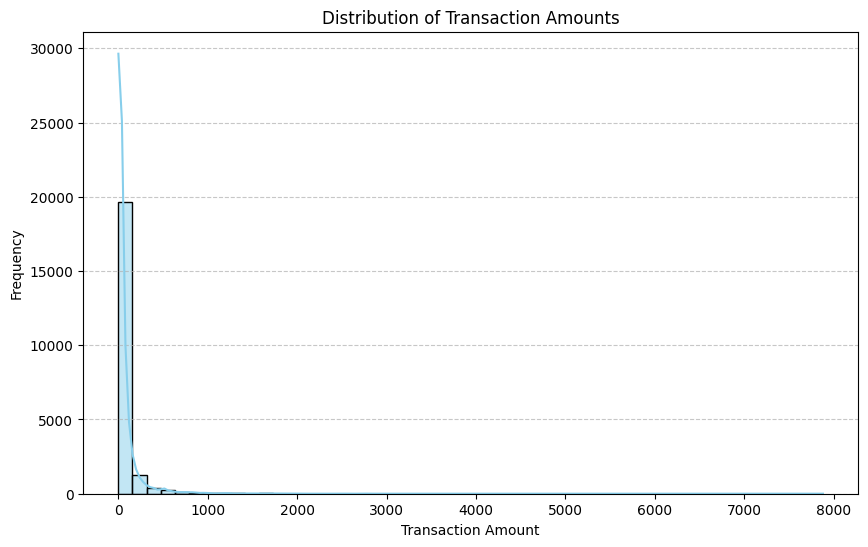


--- Chart Interpretation ---
The histogram illustrates the distribution of transaction amounts in the dataset.
- X-axis: Represents the transaction amount.
- Y-axis: Represents the frequency (number of transactions) for each amount range.
Insight: The histogram shows that a vast majority of transactions are concentrated at lower amounts, resulting in a highly skewed distribution.
There are very few transactions with high amounts, indicating that larger transactions are much less frequent. This distribution is typical for financial transaction datasets.
--------------------------


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of the 'Amount' feature
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The histogram illustrates the distribution of transaction amounts in the dataset.")
print(f"- X-axis: Represents the transaction amount.")
print(f"- Y-axis: Represents the frequency (number of transactions) for each amount range.")
print(f"Insight: The histogram shows that a vast majority of transactions are concentrated at lower amounts, resulting in a highly skewed distribution.")
print(f"There are very few transactions with high amounts, indicating that larger transactions are much less frequent. This distribution is typical for financial transaction datasets.")
print(f"--------------------------")

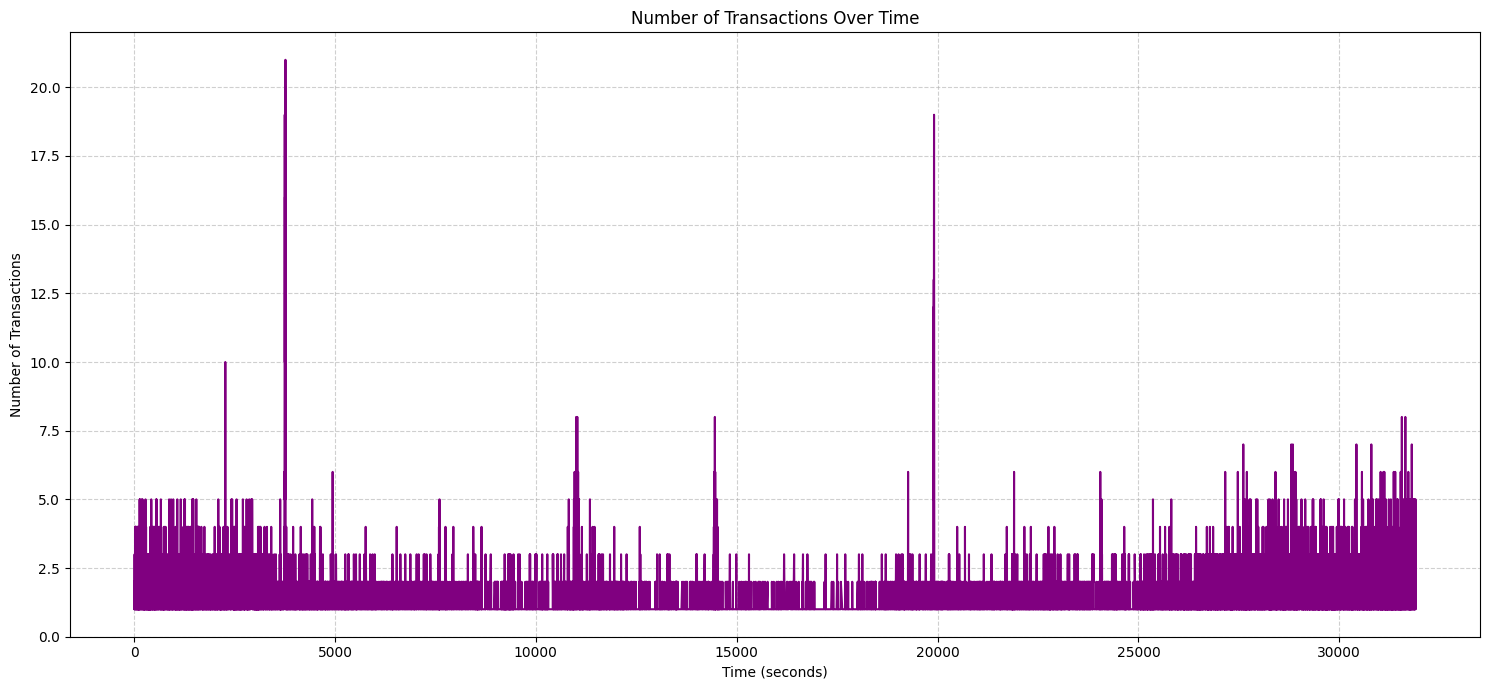


--- Chart Interpretation ---
The line chart illustrates the volume of transactions over the 'Time' variable (likely elapsed seconds from the first transaction).
- X-axis: Represents the chronological progression of time.
- Y-axis: Shows the number of transactions occurring at each specific time point.
Insight: This chart reveals patterns and trends in transaction activity throughout the observed period. Fluctuations in the line indicate variations in transaction volume, which can be useful for identifying peak activity times, periods of low activity, or any unusual spikes/drops. For example, consistent peaks and troughs might suggest daily or weekly cycles in transaction processing.
--------------------------


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Time' and count the number of transactions for each time point
transactions_over_time = df.groupby('Time').size()

# Create a line plot
plt.figure(figsize=(15, 7))
sns.lineplot(x=transactions_over_time.index, y=transactions_over_time.values, color='purple')
plt.title('Number of Transactions Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Transactions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The line chart illustrates the volume of transactions over the 'Time' variable (likely elapsed seconds from the first transaction).")
print(f"- X-axis: Represents the chronological progression of time.")
print(f"- Y-axis: Shows the number of transactions occurring at each specific time point.")
print(f"Insight: This chart reveals patterns and trends in transaction activity throughout the observed period. Fluctuations in the line indicate variations in transaction volume, which can be useful for identifying peak activity times, periods of low activity, or any unusual spikes/drops. For example, consistent peaks and troughs might suggest daily or weekly cycles in transaction processing.")
print(f"--------------------------")

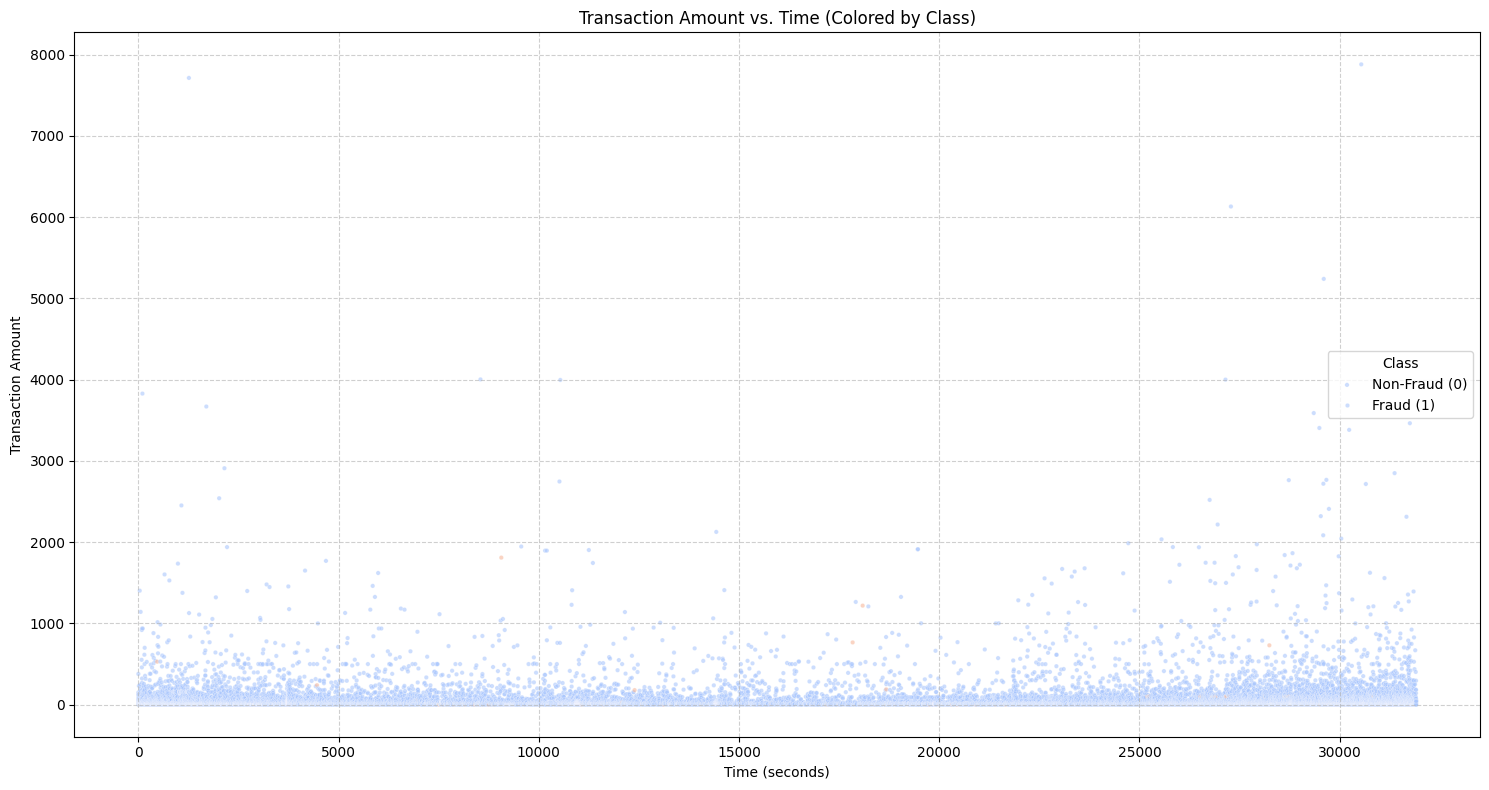


--- Chart Interpretation ---
The scatter plot visualizes the distribution of transaction amounts over time, with fraudulent transactions highlighted in a different color.
- X-axis: Represents the time elapsed from the first transaction.
- Y-axis: Represents the transaction amount.
- Color: Differentiates between non-fraudulent (Class 0) and fraudulent (Class 1) transactions.
Insight: This chart helps in identifying potential patterns or anomalies related to fraudulent activities. For instance, fraud transactions might cluster at specific times or within certain amount ranges, or appear as outliers. Observing the distribution of the red points (fraudulent transactions) can reveal if they occur during particular time windows or if they tend to involve unusually high or low amounts compared to regular transactions. This visual analysis is crucial for understanding the characteristics of fraud.
--------------------------


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the relationship between Time, Amount, and Class
plt.figure(figsize=(15, 8))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.6, palette='coolwarm', s=10)
plt.title('Transaction Amount vs. Time (Colored by Class)')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Class', labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The scatter plot visualizes the distribution of transaction amounts over time, with fraudulent transactions highlighted in a different color.")
print(f"- X-axis: Represents the time elapsed from the first transaction.")
print(f"- Y-axis: Represents the transaction amount.")
print(f"- Color: Differentiates between non-fraudulent (Class 0) and fraudulent (Class 1) transactions.")
print(f"Insight: This chart helps in identifying potential patterns or anomalies related to fraudulent activities. For instance, fraud transactions might cluster at specific times or within certain amount ranges, or appear as outliers. Observing the distribution of the red points (fraudulent transactions) can reveal if they occur during particular time windows or if they tend to involve unusually high or low amounts compared to regular transactions. This visual analysis is crucial for understanding the characteristics of fraud.")
print(f"--------------------------")

/tmp/ipykernel_2486/2694612282.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='viridis')


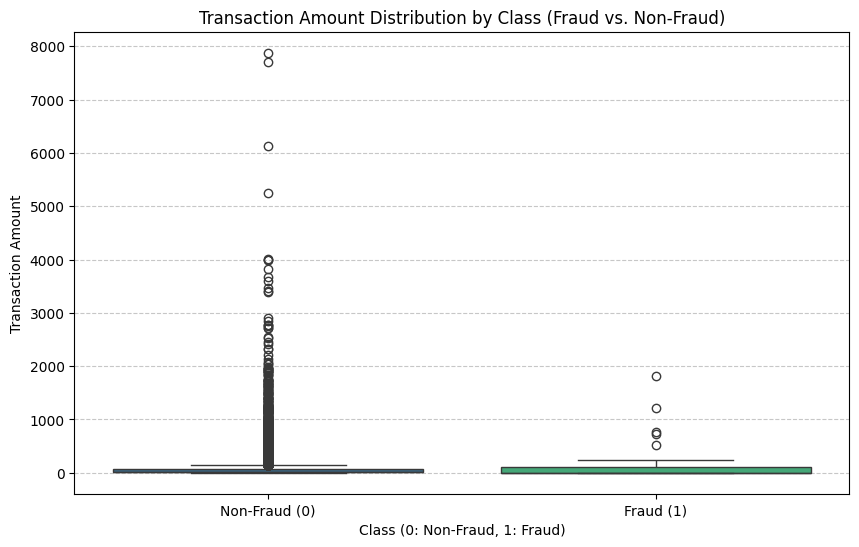


--- Chart Interpretation ---
The box plot visualizes the distribution of transaction amounts for both non-fraudulent (Class 0) and fraudulent (Class 1) transactions.
- X-axis: Differentiates between non-fraud (0) and fraud (1) transactions.
- Y-axis: Represents the transaction amount.
Insight: This chart provides key statistical summaries for each class, including the median, quartiles (25th and 75th percentiles), and potential outliers (points beyond the whiskers).
Specifically, it helps to understand if fraudulent transactions tend to have significantly different amounts (e.g., higher or lower median amounts, or a wider spread) compared to non-fraudulent transactions. Outliers in either category are also clearly visible, which can be crucial for anomaly detection.
--------------------------


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to compare transaction amounts for fraud vs. non-fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df, palette='viridis')
plt.title('Transaction Amount Distribution by Class (Fraud vs. Non-Fraud)')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The box plot visualizes the distribution of transaction amounts for both non-fraudulent (Class 0) and fraudulent (Class 1) transactions.")
print(f"- X-axis: Differentiates between non-fraud (0) and fraud (1) transactions.")
print(f"- Y-axis: Represents the transaction amount.")
print(f"Insight: This chart provides key statistical summaries for each class, including the median, quartiles (25th and 75th percentiles), and potential outliers (points beyond the whiskers).")
print(f"Specifically, it helps to understand if fraudulent transactions tend to have significantly different amounts (e.g., higher or lower median amounts, or a wider spread) compared to non-fraudulent transactions. Outliers in either category are also clearly visible, which can be crucial for anomaly detection.")
print(f"--------------------------")

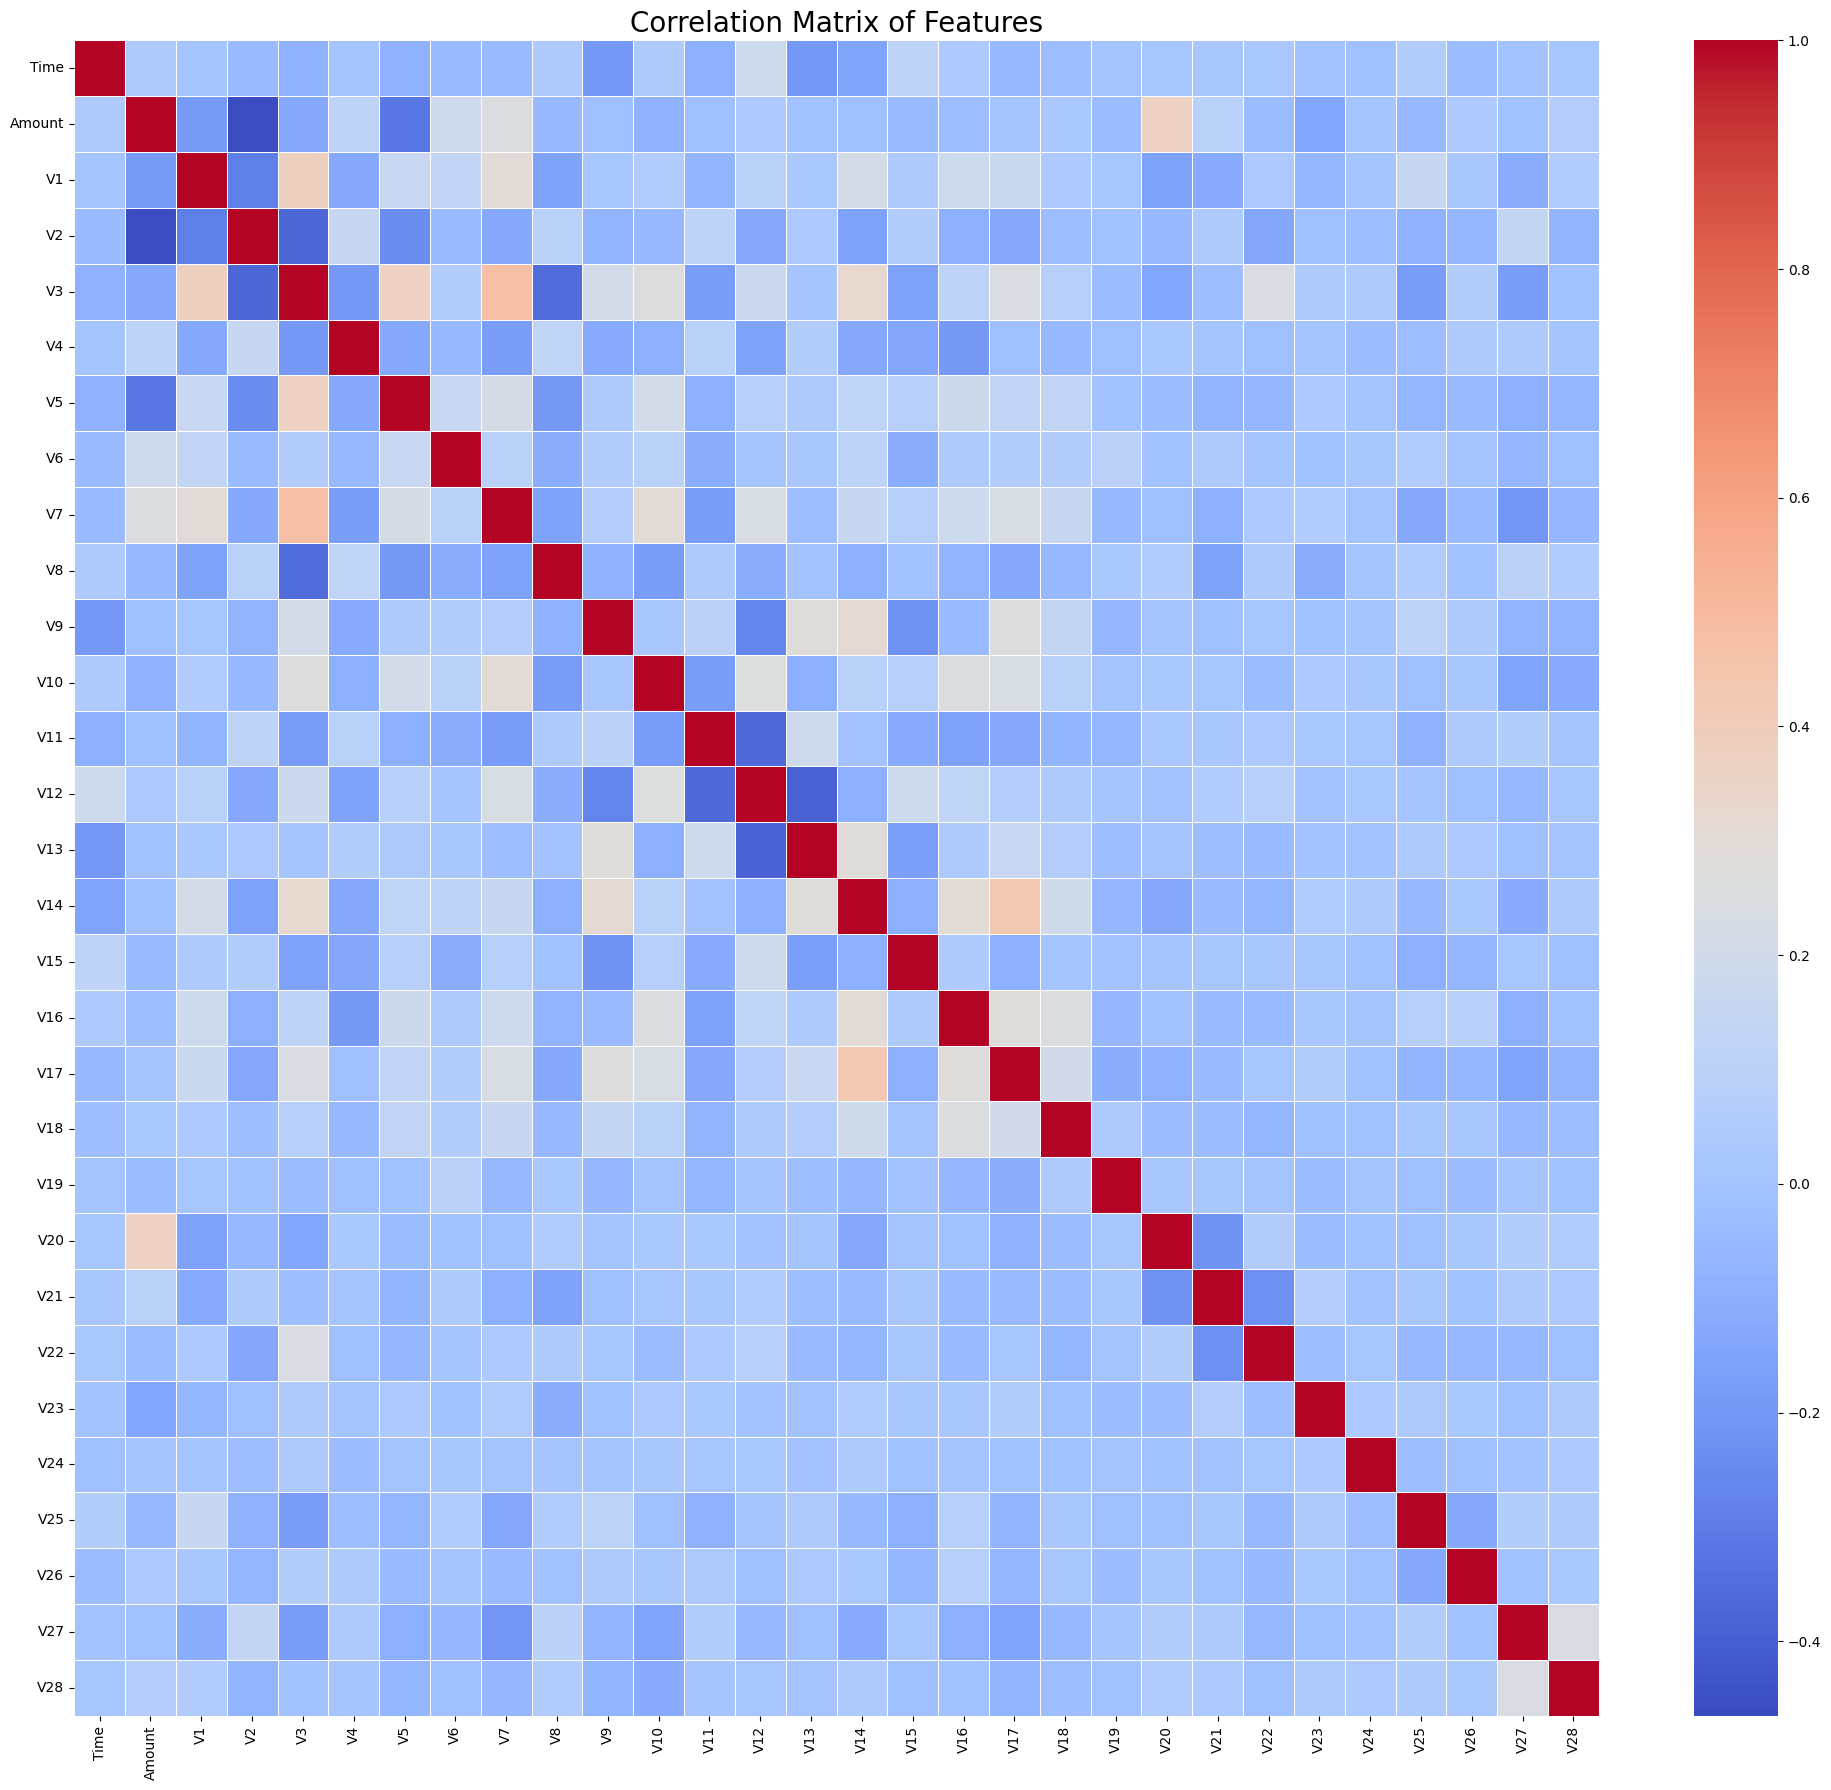


--- Chart Interpretation ---
The heatmap visualizes the Pearson correlation coefficients between the selected features (Time, Amount, and V1-V28).
- Colors indicate the strength and direction of the correlation: red shades represent positive correlation, blue shades represent negative correlation, and lighter colors (closer to white) indicate weaker correlation (closer to zero).
- A value of +1 means a perfect positive linear relationship, while -1 means a perfect negative linear relationship.
Insight: This heatmap helps in identifying highly correlated features. Strong correlations (positive or negative) can be important for feature selection, dimensionality reduction, or understanding potential multicollinearity issues in machine learning models. For instance, if two V features are highly correlated, one might be redundant. Low correlations suggest independent features. The 'Time' and 'Amount' features' correlations with other 'V' features can also provide insights into their relati

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select relevant features for correlation analysis
# The V features are anonymized, 'Time' and 'Amount' are original features.
features_for_correlation = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]

# Calculate the correlation matrix
correlation_matrix = df[features_for_correlation].corr()

# Create a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The heatmap visualizes the Pearson correlation coefficients between the selected features (Time, Amount, and V1-V28).")
print(f"- Colors indicate the strength and direction of the correlation: red shades represent positive correlation, blue shades represent negative correlation, and lighter colors (closer to white) indicate weaker correlation (closer to zero).")
print(f"- A value of +1 means a perfect positive linear relationship, while -1 means a perfect negative linear relationship.")
print(f"Insight: This heatmap helps in identifying highly correlated features. Strong correlations (positive or negative) can be important for feature selection, dimensionality reduction, or understanding potential multicollinearity issues in machine learning models. For instance, if two V features are highly correlated, one might be redundant. Low correlations suggest independent features. The 'Time' and 'Amount' features' correlations with other 'V' features can also provide insights into their relationship with the anonymized components of the transaction data.")
print(f"--------------------------")

/tmp/ipykernel_2486/4048091080.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Class', y='Amount', data=df, palette='muted')


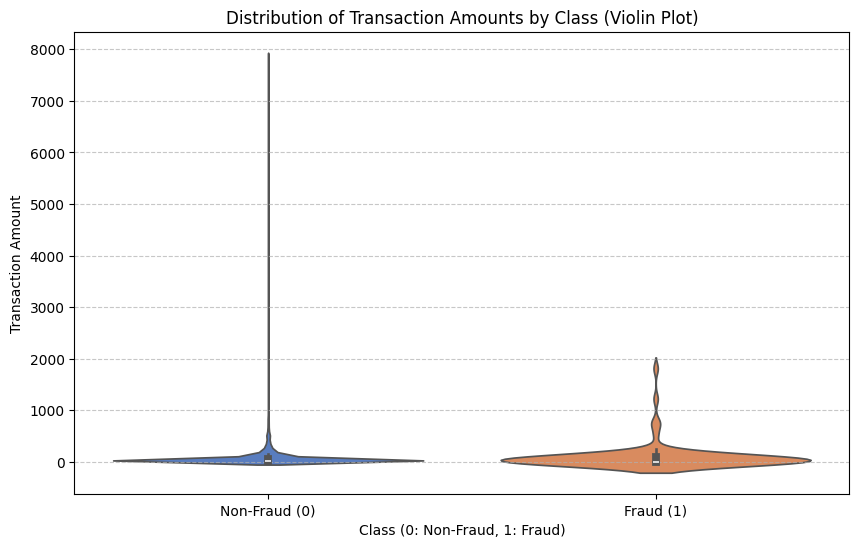


--- Chart Interpretation ---
The violin plot visualizes the distribution and density of transaction amounts for both non-fraudulent (Class 0) and fraudulent (Class 1) transactions.
- X-axis: Differentiates between non-fraud (0) and fraud (1) transactions.
- Y-axis: Represents the transaction amount.
Insight: Unlike a box plot which shows quartiles, a violin plot shows the full distribution of the data (density estimation). The wider sections of the violin indicate a higher probability density for transactions at that particular amount, while the thinner sections indicate lower density.
This plot helps in understanding the shape of the amount distribution for each class, identifying where most transactions fall, and revealing if fraudulent transactions concentrate around specific amount ranges or exhibit a different distribution pattern compared to non-fraudulent ones. It can also highlight outliers and skewness more effectively than a simple box plot.
--------------------------


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a violin plot to visualize the distribution of amounts by class
plt.figure(figsize=(10, 6))
sns.violinplot(x='Class', y='Amount', data=df, palette='muted')
plt.title('Distribution of Transaction Amounts by Class (Violin Plot)')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The violin plot visualizes the distribution and density of transaction amounts for both non-fraudulent (Class 0) and fraudulent (Class 1) transactions.")
print(f"- X-axis: Differentiates between non-fraud (0) and fraud (1) transactions.")
print(f"- Y-axis: Represents the transaction amount.")
print(f"Insight: Unlike a box plot which shows quartiles, a violin plot shows the full distribution of the data (density estimation). The wider sections of the violin indicate a higher probability density for transactions at that particular amount, while the thinner sections indicate lower density.")
print(f"This plot helps in understanding the shape of the amount distribution for each class, identifying where most transactions fall, and revealing if fraudulent transactions concentrate around specific amount ranges or exhibit a different distribution pattern compared to non-fraudulent ones. It can also highlight outliers and skewness more effectively than a simple box plot.")
print(f"--------------------------")

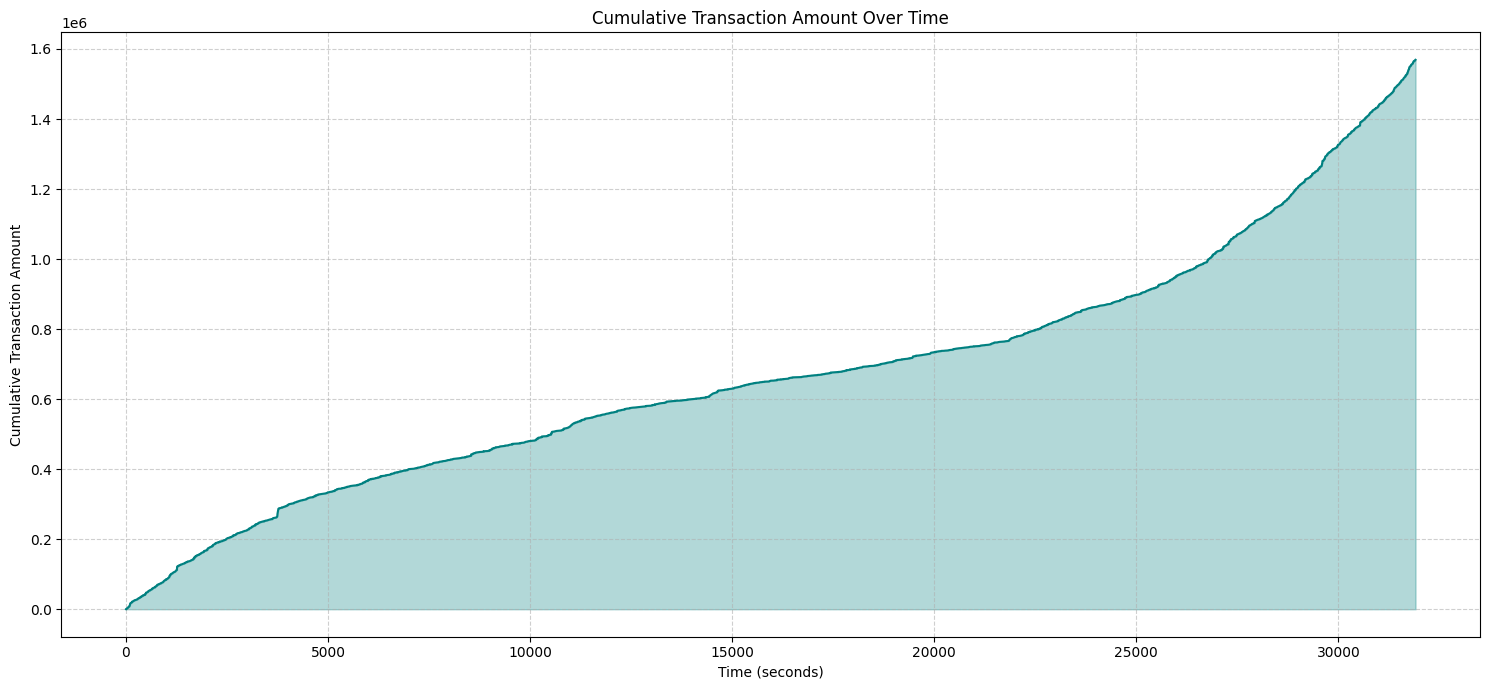


--- Chart Interpretation ---
The area chart visualizes the cumulative sum of transaction amounts over time.
- X-axis: Represents the chronological progression of time (in seconds).
- Y-axis: Shows the total cumulative transaction amount up to each given time point.
Insight: This chart provides a clear view of the overall growth of transaction value over the observed period. A steadily rising curve indicates consistent accumulation of transaction value. Any significant changes in the slope of the curve could suggest periods of accelerated or decelerated growth in transaction value. This is useful for understanding the long-term financial activity and trends in the dataset.
--------------------------


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Time' and sum the 'Amount' for each time point
daily_amount = df.groupby('Time')['Amount'].sum().reset_index()

# Calculate the cumulative sum of 'Amount' over time
daily_amount['Cumulative_Amount'] = daily_amount['Amount'].cumsum()

# Create an area chart (using lineplot with fill_between)
plt.figure(figsize=(15, 7))
sns.lineplot(x='Time', y='Cumulative_Amount', data=daily_amount, color='teal')
plt.fill_between(daily_amount['Time'], daily_amount['Cumulative_Amount'], color='teal', alpha=0.3)
plt.title('Cumulative Transaction Amount Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Cumulative Transaction Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The area chart visualizes the cumulative sum of transaction amounts over time.")
print(f"- X-axis: Represents the chronological progression of time (in seconds).")
print(f"- Y-axis: Shows the total cumulative transaction amount up to each given time point.")
print(f"Insight: This chart provides a clear view of the overall growth of transaction value over the observed period. A steadily rising curve indicates consistent accumulation of transaction value. Any significant changes in the slope of the curve could suggest periods of accelerated or decelerated growth in transaction value. This is useful for understanding the long-term financial activity and trends in the dataset.")
print(f"--------------------------")

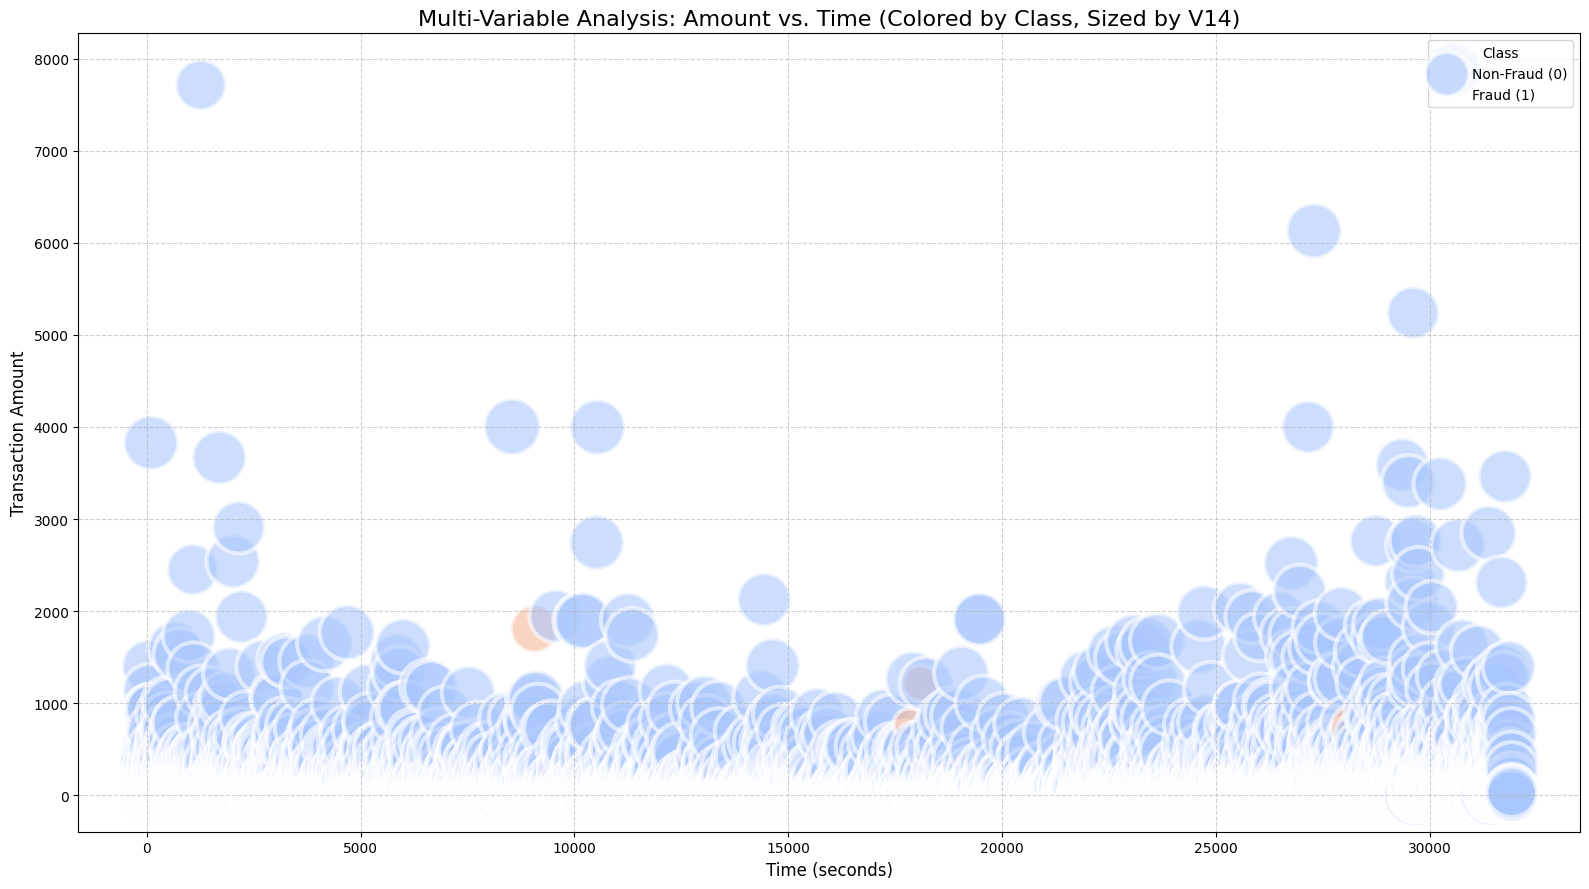


--- Chart Interpretation ---
The bubble chart visualizes the relationships between 'Time', 'Amount', 'Class', and 'V14' (or 'V17' if chosen) in a single plot.
- X-axis: Represents the time elapsed from the first transaction.
- Y-axis: Represents the transaction amount.
- Bubble Color: Differentiates between non-fraudulent (Class 0) and fraudulent (Class 1) transactions.
- Bubble Size: Indicates the magnitude of the 'V14' feature (or 'V17'), with larger bubbles corresponding to higher values.
Insight: This chart is powerful for identifying complex patterns that involve multiple variables. For instance, it can reveal if fraudulent transactions (red bubbles) tend to occur at specific times, with particular amounts, and are also associated with unusually high or low values of the V14 feature. Clusters of large, red bubbles in certain areas of the plot would indicate a higher propensity for fraud under those conditions. This helps in understanding the multi-faceted characteristics that dis

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bubble chart to visualize Time, Amount, Class, and V14 (or V17)
plt.figure(figsize=(16, 9))
sns.scatterplot(
    x='Time',
    y='Amount',
    hue='Class',        # Color by Class (fraud vs. non-fraud)
    size='V14',         # Bubble size by V14 (or V17, chosen V14 for this example)
    sizes=(20, 2000),   # Range of bubble sizes
    alpha=0.6,          # Transparency of bubbles
    palette='coolwarm', # Color palette for Class
    data=df
)
plt.title('Multi-Variable Analysis: Amount vs. Time (Colored by Class, Sized by V14)', fontsize=16)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Transaction Amount', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Class', labels=['Non-Fraud (0)', 'Fraud (1)'], loc='upper right')
plt.tight_layout()
plt.show()

# Explicit interpretation printed to output:
print(f"\n--- Chart Interpretation ---")
print(f"The bubble chart visualizes the relationships between 'Time', 'Amount', 'Class', and 'V14' (or 'V17' if chosen) in a single plot.")
print(f"- X-axis: Represents the time elapsed from the first transaction.")
print(f"- Y-axis: Represents the transaction amount.")
print(f"- Bubble Color: Differentiates between non-fraudulent (Class 0) and fraudulent (Class 1) transactions.")
print(f"- Bubble Size: Indicates the magnitude of the 'V14' feature (or 'V17'), with larger bubbles corresponding to higher values.")
print(f"Insight: This chart is powerful for identifying complex patterns that involve multiple variables. For instance, it can reveal if fraudulent transactions (red bubbles) tend to occur at specific times, with particular amounts, and are also associated with unusually high or low values of the V14 feature. Clusters of large, red bubbles in certain areas of the plot would indicate a higher propensity for fraud under those conditions. This helps in understanding the multi-faceted characteristics that distinguish fraudulent from legitimate transactions.")
print(f"--------------------------")